In [1]:
import numpy as np
import matplotlib.pyplot as plt
from collections.abc import Iterable
from matplotlib.patches import Patch  # Per creare elementi di legenda personalizzati

In [2]:
#confronto for-single thread con par_for_sure_n con n_blocchi variabile
def plot_granularity(data_for, data_par_for_n,title):
    fig, ax = plt.subplots(figsize=[10, 8])
    
    boxs = []
    ticks = []
    boxs.append(data_for)
    ticks.append("for")
    for i in range(len(data_par_for_n)):
        boxs.append(data_par_for_n[i])
        ticks.append(str(granularity[i]))

    
    bplot = ax.boxplot(boxs, showfliers=False, patch_artist=True)

    ax.set(xlabel = 'iterazioni per job',ylabel = 'Microseconds')
    ax.set_title( title, loc = 'left')
    ax.set_xticks(range(1,1+len(boxs)),ticks)

    # Colora ogni box
    colors = ['orange'] + ['blue'] * (len(bplot['boxes']) - 1)
    for box, color in zip(bplot['boxes'], colors):
        box.set_facecolor(color)

    # Crea legenda con Patch
    legend_handles = [
        Patch(facecolor='orange', label='for'),
        Patch(facecolor='blue', label='parallel_for')
    ]
    ax.legend(handles=legend_handles, loc='upper right')

    plt.figtext(0.63, 0.9, f"threadpool: n_thread({n_threads}), size_queue({size_queue})\nmatrix size: {n_size}", fontsize=9, 
            bbox=dict(facecolor='white', edgecolor='black'))

In [3]:
def plot_speedup_granularity(data_list,title,gran,n_threads): #primo data in data_list è for normale e poi si compara con quello
    fig, ax = plt.subplots(figsize=[16, 8])

    data_mean = [np.mean(datum) for datum in data_list]
    speedup = np.zeros(len(gran))


    for i in range(len(gran)):
        speedup[i] = data_mean[0]/data_mean[i+1]
        

    #print(data_list)
    #print(data_mean)
    gran = gran[::-1]
    speedup = speedup[::-1]
    ax.plot(gran,speedup,'o--')

    y = lambda x: np.minimum(n_size/x,n_threads)
    ax.plot(gran,y(np.array(gran)), 'o--')

    ax.legend(['speedup','maximum'])
    ax.set_title(title, loc= 'left')
    ax.set_xticks(gran)
    ax.set_xticklabels(gran, rotation = 45)


    ax.set(xlabel = 'graularity'+str(gran),ylabel = 'speedup')
    plt.figtext(0.7, 0.9, f"threadpool: n_thread({n_threads}), size_queue({size_queue})\nmatrix size: {n_size}", fontsize=9, 
            bbox=dict(facecolor='white', edgecolor='black'))

## prestazioni parallel_for_sure_n con n_blocchi (blocchi in cui si divide range di for) variabile

In [4]:
!rm *.txt

rm: cannot remove '*.txt': No such file or directory


In [18]:
#a mano settali uguali a come runnato in cluster 
#set parameter
n_runs = 50
n_size = 1600 #costo singola iterazione
n_threads = 8
size_queue = 256
granularity = [1600,800,400,200,10]

In [ ]:
#run manualmente for seq,   nruns sizematrix
!./for.sh 50 1600

In [ ]:
# eigen A+B
!./for_eigen.sh 5 1200

In [ ]:
#run granularity for (per ogni n un run di .sh) runs sizematrix thread queuesize granularity
!./parallel_for.sh 50 10000 4 64 4

In [56]:
# run test granularity
dati_for = []
dati_for = np.genfromtxt("test_for_matrix.txt",delimiter=',',dtype=int)[:-1]
dati_parallel_for_sure_gran = []
for i,nb in enumerate(granularity):
    dati_parallel_for_sure_gran.append(np.genfromtxt("test_parallel_for_matrix_gr"+str(nb)+".txt",delimiter=',',dtype=int)[:-1])

In [27]:
#TEST vs EIGEN
# run test granularity
dati_for = []
dati_for = np.genfromtxt("test_Eigen_for.txt",delimiter=',',dtype=int)[:-1]
dati_parallel_for_sure_gran = []
for i,nb in enumerate(granularity):
    dati_parallel_for_sure_gran.append(np.genfromtxt("test_parallel_for_matrix_gr"+str(nb)+".txt",delimiter=',',dtype=int)[:-1])

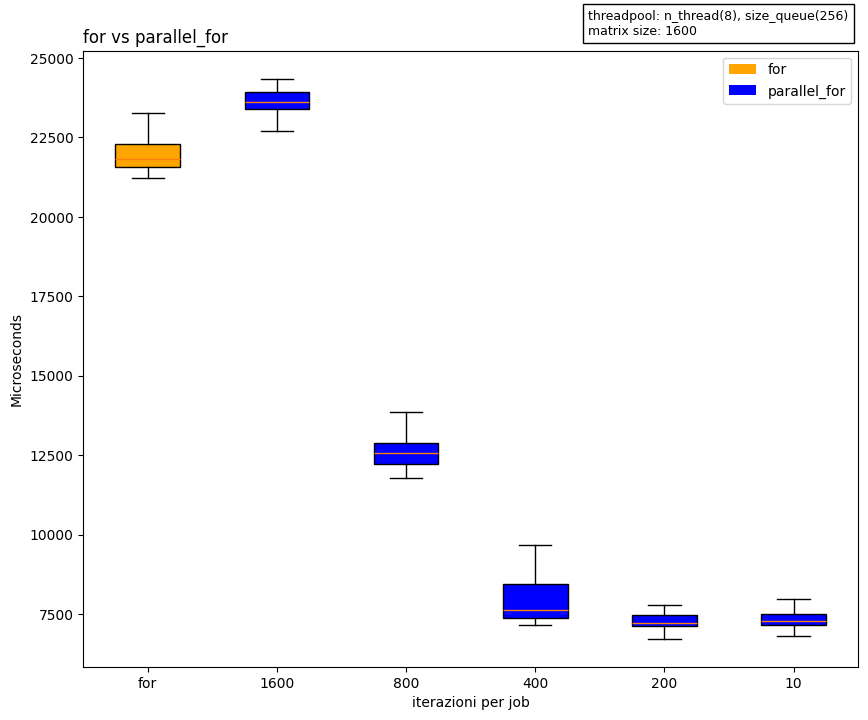

In [57]:
plot_granularity(dati_for, dati_parallel_for_sure_gran,"for vs parallel_for")

su 50 iniziali tenuti 49 per for sequential
su 50 iniziali tenuti 47 per granularity 1600
su 50 iniziali tenuti 45 per granularity 800
su 50 iniziali tenuti 44 per granularity 400
su 50 iniziali tenuti 50 per granularity 200
su 50 iniziali tenuti 50 per granularity 10


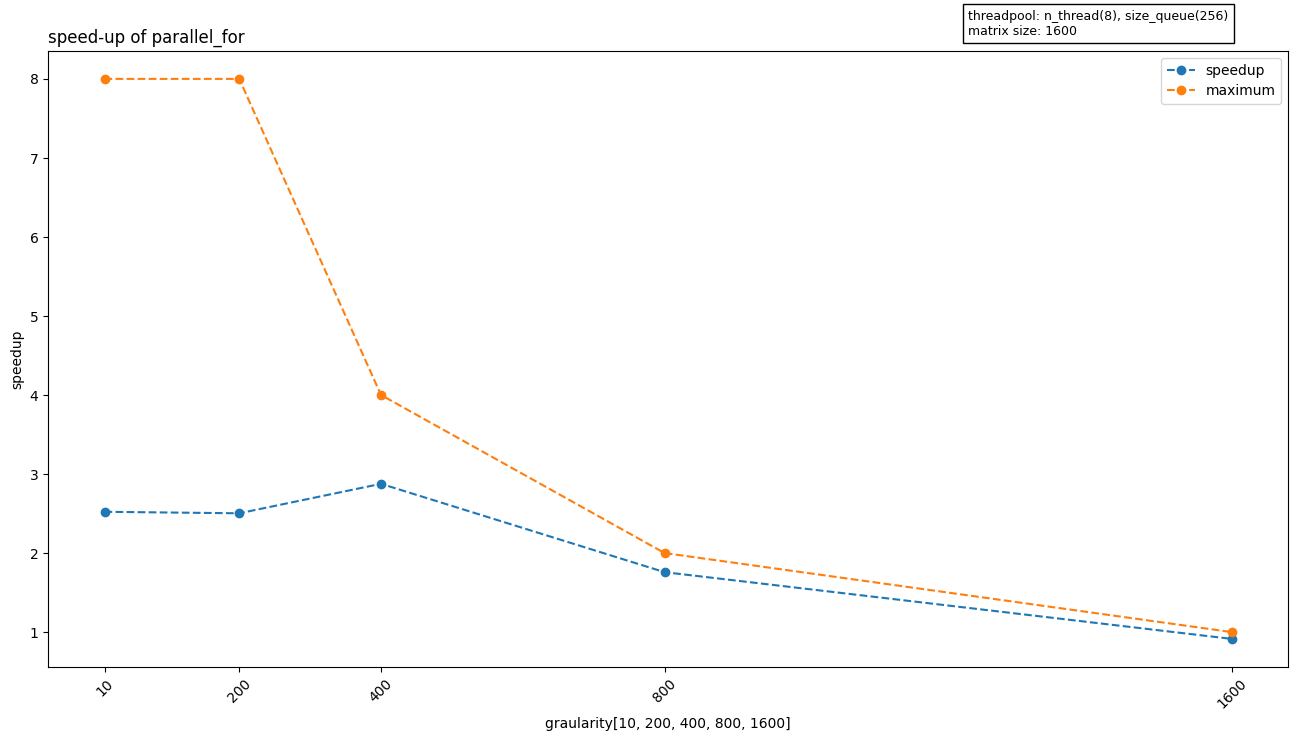

In [27]:
data_list = []
data_list.append(dati_for)
# Calcolo Q1, Q3 e IQR
Q1 = np.percentile(data_list[0], 25)
Q3 = np.percentile(data_list[0], 75)
IQR = Q3 - Q1

# Limiti per gli outlier
limite_inferiore = Q1 - 1.5 * IQR
limite_superiore = Q3 + 1.5 * IQR
#print(Q1,Q3,IQR,limite_inferiore,limite_superiore)
# Filtro
data_list[0] = data_list[0][(data_list[0] >= limite_inferiore) & (data_list[0] <= limite_superiore)]
print(f"su {len(dati_for)} iniziali tenuti {len(data_list[0])} per for sequential")
for i in range(len(granularity)):
    data_list.append(dati_parallel_for_sure_gran[i])
    # Calcolo Q1, Q3 e IQR
    Q1 = np.percentile(data_list[i+1], 25)
    Q3 = np.percentile(data_list[i+1], 75)
    IQR = Q3 - Q1

    # Limiti per gli outlier
    limite_inferiore = Q1 - 1.5 * IQR
    limite_superiore = Q3 + 1.5 * IQR
   # print(Q1,Q3,IQR,limite_inferiore,limite_superiore)
    # Filtro
    data_list[i+1] = data_list[i+1][(data_list[i+1] >= limite_inferiore) & (data_list[i+1] <= limite_superiore)]
    print(f"su {len(dati_parallel_for_sure_gran[0])} iniziali tenuti {len(data_list[i+1])} per granularity {granularity[i]}")
plot_speedup_granularity(data_list,"speed-up of parallel_for",granularity,n_threads)

## confronto parallel_for openmp

In [31]:
#confronto for-single thread con par_for_sure_n con n_blocchi variabile
def plot_openmp(data_for, data_par_for_n,title):
    fig, ax = plt.subplots(figsize=[10, 8])
    
    boxs = []
    ticks = []
    boxs.append(data_for)
    ticks.append("for")
    for i in range(len(data_par_for_n)):
        boxs.append(data_par_for_n[i])
        ticks.append(str(n_threads_open[i]))

    
    bplot = ax.boxplot(boxs, showfliers=False, patch_artist=True)

    ax.set(xlabel = 'thread',ylabel = 'Microseconds')
    ax.set_title( title, loc = 'left')
    ax.set_xticks(range(1,1+len(boxs)),ticks)

    # Colora ogni box
    colors = ['orange'] + ['blue'] * (len(bplot['boxes']) - 1)
    for box, color in zip(bplot['boxes'], colors):
        box.set_facecolor(color)

    # Crea legenda con Patch
    legend_handles = [
        Patch(facecolor='orange', label='for'),
        Patch(facecolor='blue', label='parallel_for_openmp')
    ]
    ax.legend(handles=legend_handles, loc='upper right')

    plt.figtext(0.63, 0.9, f"matrix size: {n_size}", fontsize=9, 
            bbox=dict(facecolor='white', edgecolor='black'))

In [42]:
def plot_speedup_openmp(data_list,title,threads): #primo data in data_list è for normale e poi si compara con quello
    fig, ax = plt.subplots(figsize=[16, 8])

    data_mean = [np.mean(datum) for datum in data_list]
    speedup = np.zeros(len(threads))


    for i in range(len(threads)):
        speedup[i] = data_mean[0]/data_mean[i+1]
        

    ax.plot(threads,speedup,'o--')

    y = lambda x: x
    ax.plot(threads,y(np.array(threads)), 'o--')

    ax.legend(['speedup','maximum'])
    ax.set_title(title, loc= 'left')
    ax.set_xticks(threads)
    ax.set_xticklabels(threads, rotation = 45)


    ax.set(xlabel = 'threads'+str(threads),ylabel = 'speedup')
    plt.figtext(0.7, 0.9, f"matrix size: {n_size}", fontsize=9, 
            bbox=dict(facecolor='white', edgecolor='black'))

In [32]:
n_threads_open = [1,2,3,4,5,6,7,8]

In [ ]:
!./for.sh 10 1600

In [ ]:
# per run for open mp (n_thread uno per volta)  nruns size nthread
!./for_openmp.sh 10 1000 4

In [51]:
# run test granularity
dati_for = []
dati_for = np.genfromtxt("test_for_matrix.txt",delimiter=',',dtype=int)[:-1]
dati_for_open = []
for i,nb in enumerate(n_threads_open):
    dati_for_open.append(np.genfromtxt("test_for_openmp_th"+str(nb)+".txt",delimiter=',',dtype=int)[:-1])

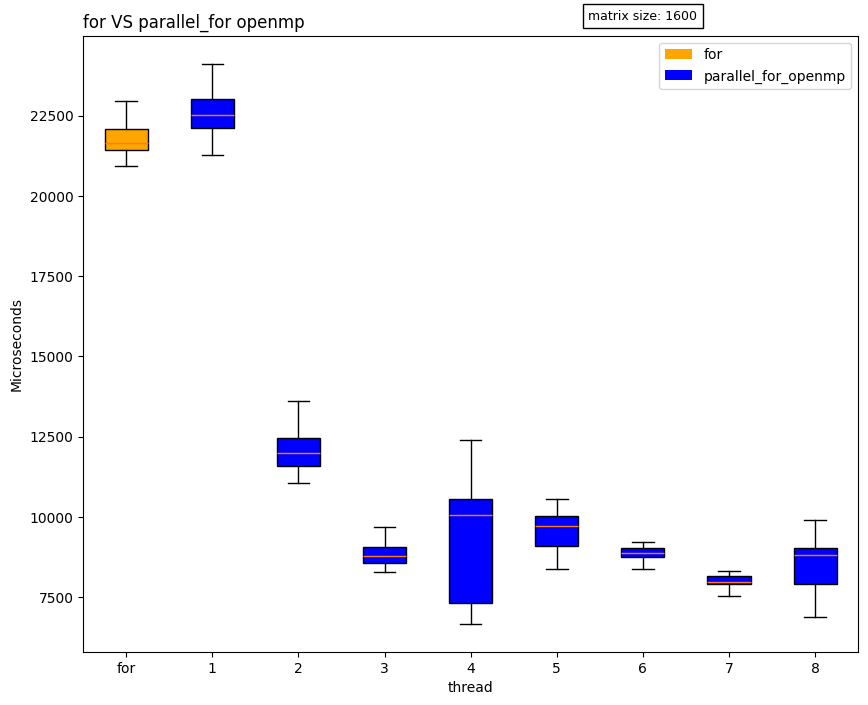

In [52]:
plot_openmp(data_for=dati_for, data_par_for_n=dati_for_open,title="for VS parallel_for openmp")

su 50 iniziali tenuti 42 per for sequential
su 50 iniziali tenuti 47 per thread 1
su 50 iniziali tenuti 48 per thread 2
su 50 iniziali tenuti 44 per thread 3
su 50 iniziali tenuti 50 per thread 4
su 50 iniziali tenuti 50 per thread 5
su 50 iniziali tenuti 47 per thread 6
su 50 iniziali tenuti 46 per thread 7
su 50 iniziali tenuti 46 per thread 8


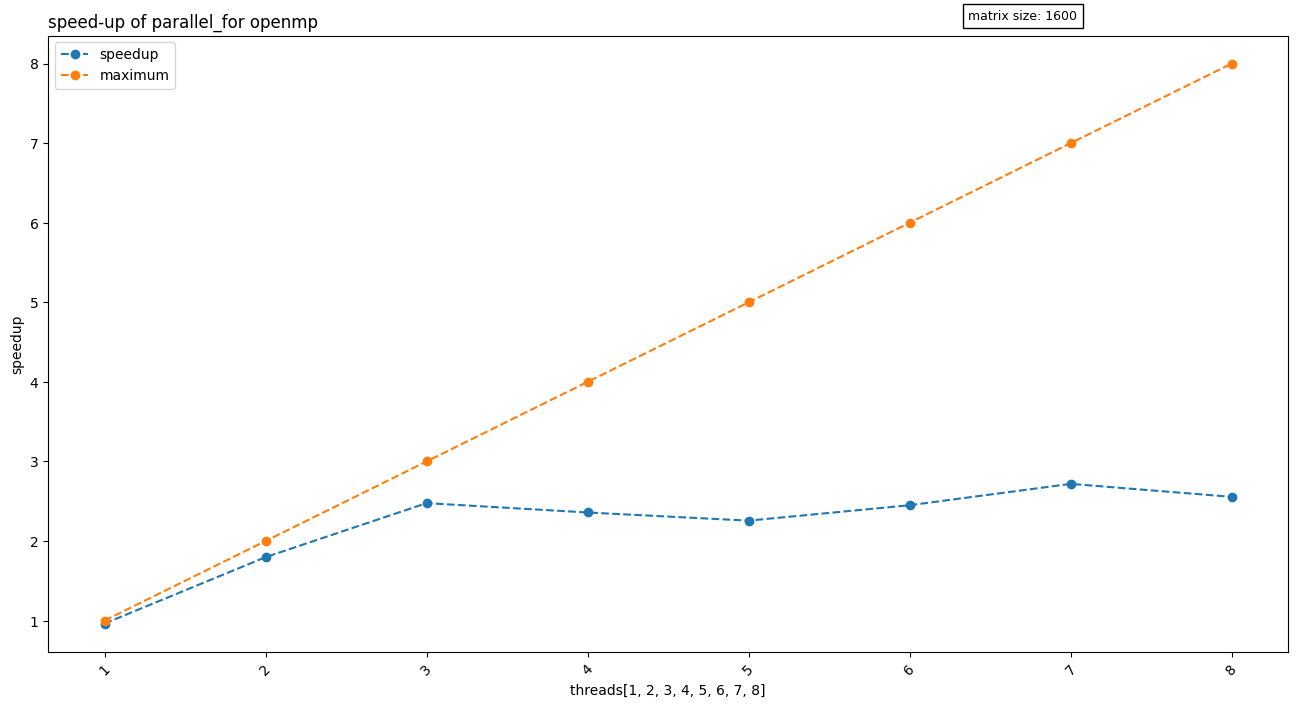

In [53]:
data_list = []
data_list.append(dati_for)
# Calcolo Q1, Q3 e IQR
Q1 = np.percentile(data_list[0], 25)
Q3 = np.percentile(data_list[0], 75)
IQR = Q3 - Q1

# Limiti per gli outlier
limite_inferiore = Q1 - 1.5 * IQR
limite_superiore = Q3 + 1.5 * IQR
#print(Q1,Q3,IQR,limite_inferiore,limite_superiore)
# Filtro
data_list[0] = data_list[0][(data_list[0] >= limite_inferiore) & (data_list[0] <= limite_superiore)]
print(f"su {len(dati_for)} iniziali tenuti {len(data_list[0])} per for sequential")
for i in range(len(n_threads_open)):
    data_list.append(dati_for_open[i])
    # Calcolo Q1, Q3 e IQR
    Q1 = np.percentile(data_list[i+1], 25)
    Q3 = np.percentile(data_list[i+1], 75)
    IQR = Q3 - Q1

    # Limiti per gli outlier
    limite_inferiore = Q1 - 1.5 * IQR
    limite_superiore = Q3 + 1.5 * IQR
   # print(Q1,Q3,IQR,limite_inferiore,limite_superiore)
    # Filtro
    data_list[i+1] = data_list[i+1][(data_list[i+1] >= limite_inferiore) & (data_list[i+1] <= limite_superiore)]
    print(f"su {len(dati_for_open[0])} iniziali tenuti {len(data_list[i+1])} per thread {n_threads_open[i]}")
plot_speedup_openmp(data_list,"speed-up of parallel_for openmp",n_threads_open)